# Notebook 06 - Matrix Determinant Lemma

Goal

Verify numerically that

det(I + γSSᴴ)=det(I + γSᴴS)

This identity is the mathematical bridge that transforms
the covariance matrix into the Gram matrix.

After this notebook,
all later computations can be performed on the small Gram matrix.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

In [3]:
# ===================================
# Radar Parameters
# ===================================

fs = 20e6
T = 20e-6
B = 5e6

N = int(fs*T)

k = B/T

print("N =", N)

N = 400


In [4]:
t = np.arange(N)/fs

t = t - T/2

s = np.exp(1j*np.pi*k*t**2)

In [5]:
def delay_signal(signal, delay):

    delayed = np.zeros_like(signal)

    delayed[delay:] = signal[:-delay]

    return delayed

In [6]:
taus = [30,100,220]

signals = []

for tau in taus:

    signals.append(
        delay_signal(s,tau)
    )

S = np.column_stack(signals)

print(S.shape)

(400, 3)


In [7]:
A = S @ S.conj().T
G = S.conj().T @ S

print(A.shape)
print(G.shape)

(400, 400)
(3, 3)


In [11]:
gamma_0 = 1
left = np.linalg.det(
    np.eye(N) + gamma_0*A
)

right = np.linalg.det(
    np.eye(G.shape[0]) + gamma_0*G
)
error = abs(left-right)

print(error)

1.4652197060674928e-07


In [14]:
gammas = np.logspace(-3,3,80)
errors = []
for gamma in gammas:

    left = np.linalg.det(
        np.eye(N)+gamma*A
    )

    right = np.linalg.det(
        np.eye(G.shape[0])+gamma*G
    )

    relative_error = abs(left-right) / abs(left)

    errors.append(relative_error)

Text(0, 0.5, 'Absolute Error')

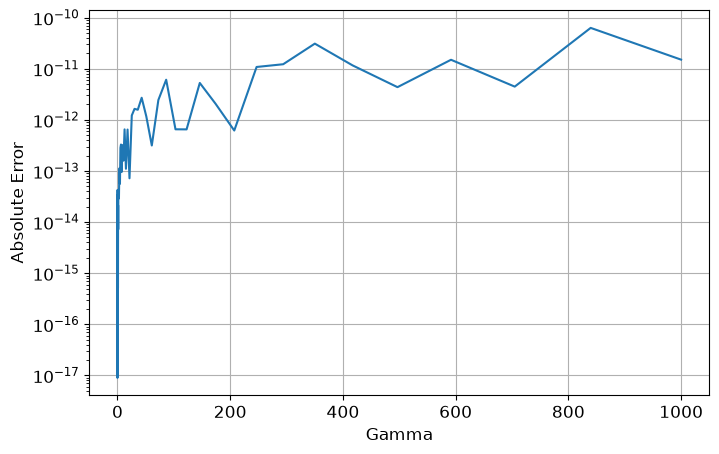

In [15]:
plt.semilogy(
    gammas,
    errors
)

plt.grid(True)

plt.xlabel("Gamma")

plt.ylabel("Absolute Error")

## Discussion

The numerical experiments verify

det(I+γSSᴴ)=det(I+γSᴴS)

Therefore,

the covariance matrix can be replaced by
the Gram matrix
without changing the determinant.

This explains why
the paper derives all later results
using the Gram matrix.